# Create Chart using Hostogram

[*********************100%***********************]  1 of 1 completed


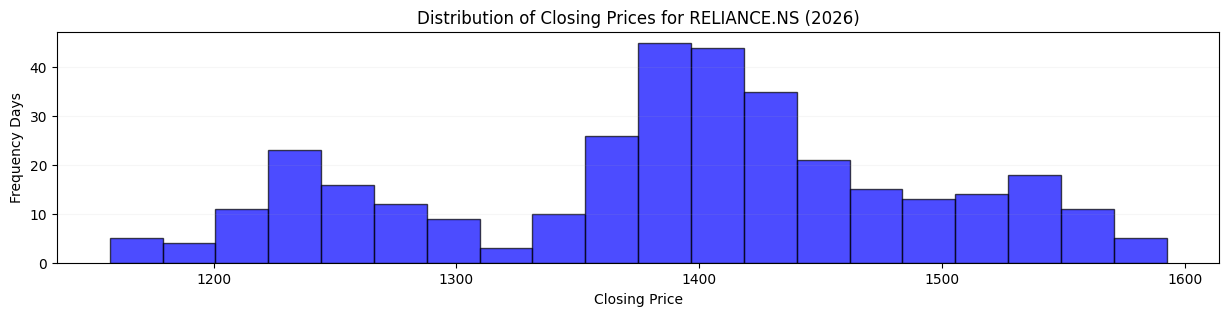

In [52]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

stock = yf.download('RELIANCE.NS', start='2025-01-01', end='2026-05-16')
plt.figure(figsize=(15, 3))
plt.hist(stock['Close'], bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Closing Prices for RELIANCE.NS (2026)')
plt.xlabel('Closing Price')
plt.ylabel('Frequency Days')
plt.grid(axis='y', alpha=0.1)
plt.show()

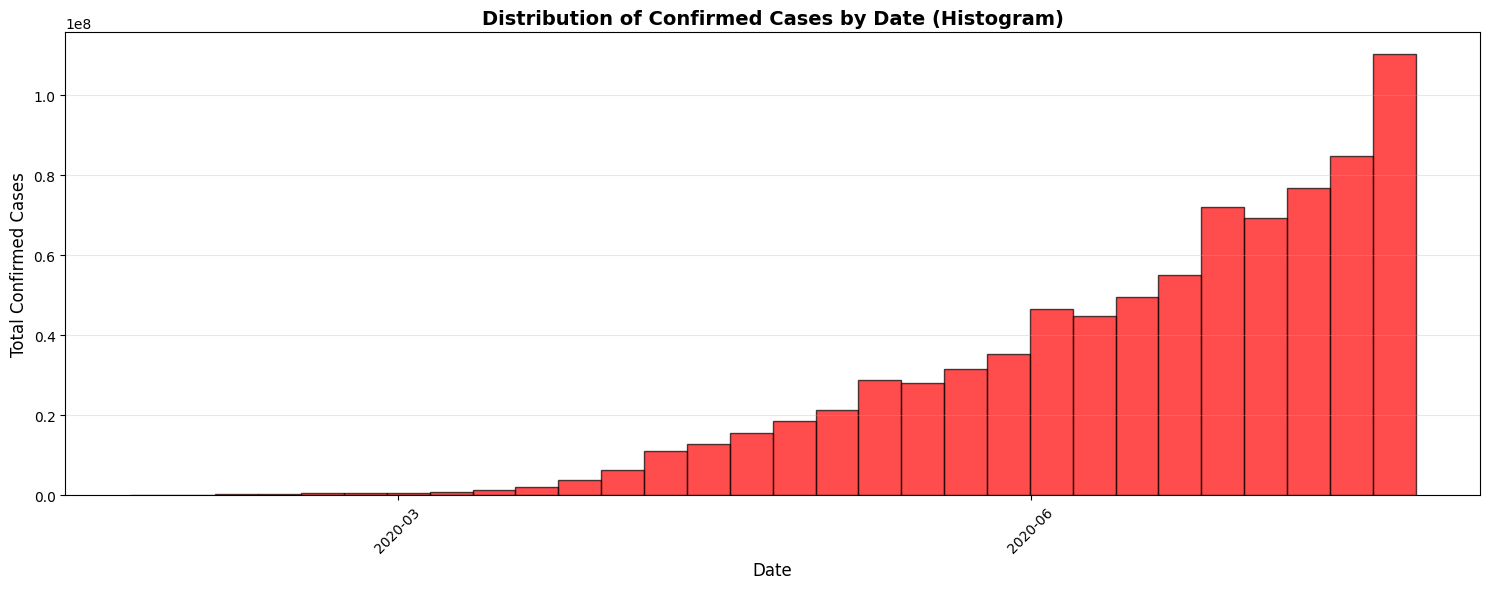


Month with highest confirmed cases: 2020-07 with 362895848 confirmed cases


In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

# Load the dataset
df = pd.read_csv('day_wise.csv')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create histogram with date on x-axis
plt.figure(figsize=(15, 6))
plt.hist(df['Date'], bins=30, weights=df['Confirmed'], color='red', alpha=0.7, edgecolor='black')
plt.title('Distribution of Confirmed Cases by Date (Histogram)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Confirmed Cases', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Extract month and find statistics
df['Month'] = df['Date'].dt.to_period('M')
monthly_cases = df.groupby('Month')['Confirmed'].sum().sort_index()

# Find month with highest confirmed cases
max_month = monthly_cases.idxmax()
max_cases = monthly_cases.max()
print(f"\nMonth with highest confirmed cases: {max_month} with {max_cases:.0f} confirmed cases")


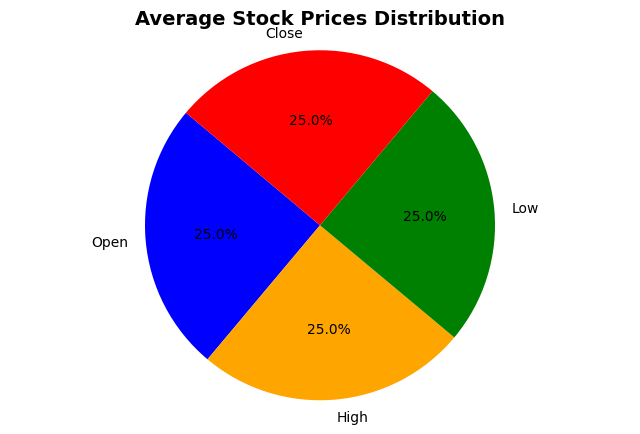

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('stock_dataset.csv')
avg_values = [df['Open'].mean(), df['High'].mean(), df['Low'].mean(), df['Close'].mean()]
labels = ['Open', 'High', 'Low', 'Close']
plt.figure(figsize=(8, 5))
plt.pie(avg_values, labels=labels, autopct='%1.1f%%', startangle=140, colors=['blue', 'orange', 'green', 'red'])
plt.title('Average Stock Prices Distribution', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()


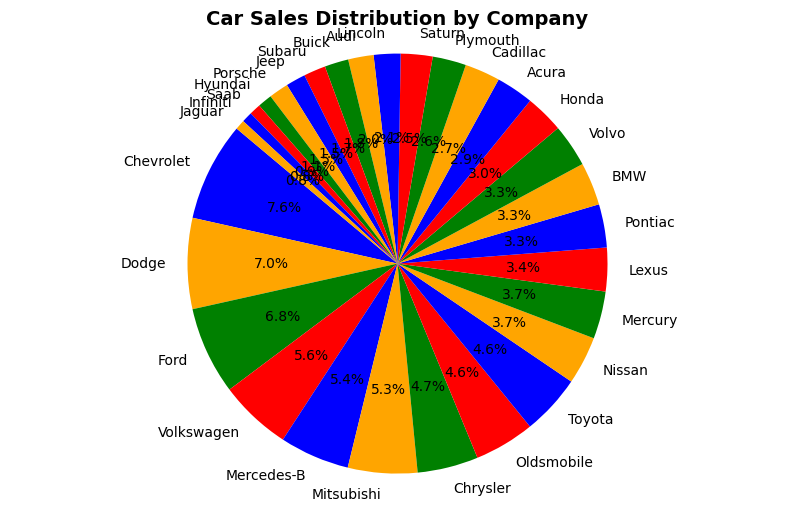

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
car_data = pd.read_csv('car sales.csv')
# get average sales by car Company
car_sales = car_data['Company'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(car_sales.values, labels=car_sales.index, autopct='%1.1f%%', startangle=140, colors=['blue', 'orange', 'green', 'red'])
plt.title('Car Sales Distribution by Company', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()



=== Stock Performance (Sorted by % Change - Ascending) ===
            % Change     Close      Volume  %Deliverble
Symbol                                                 
ICICIBANK      -1.41    527.50  13592625.0       0.3313
HINDALCO       -0.91    238.35   5091899.0       0.1986
HDFCBANK       -0.78   1425.05   4405469.0       0.3237
VEDL           -0.62    160.40   9590065.0       0.1484
TITAN          -0.55   1558.60   1003018.0       0.2954
BAJAJFINSV     -0.40   8870.45    288101.0       0.2072
HINDUNILVR     -0.33   2387.55    830096.0       0.3173
NTPC           -0.30     99.05  13493039.0       0.3340
BAJFINANCE     -0.28   5280.15   1447187.0       0.1712
SHREECEM       -0.26  23950.30     50972.0       0.2154
BRITANNIA      -0.24   3567.80    453083.0       0.4176
HEROMOTOCO     -0.24   3102.65    408952.0       0.2374
POWERGRID      -0.18    189.50   1729475.0       0.2906
TATASTEEL      -0.09    643.10   8411396.0       0.1082
KOTAKBANK      -0.08   1994.05   1106099.0  

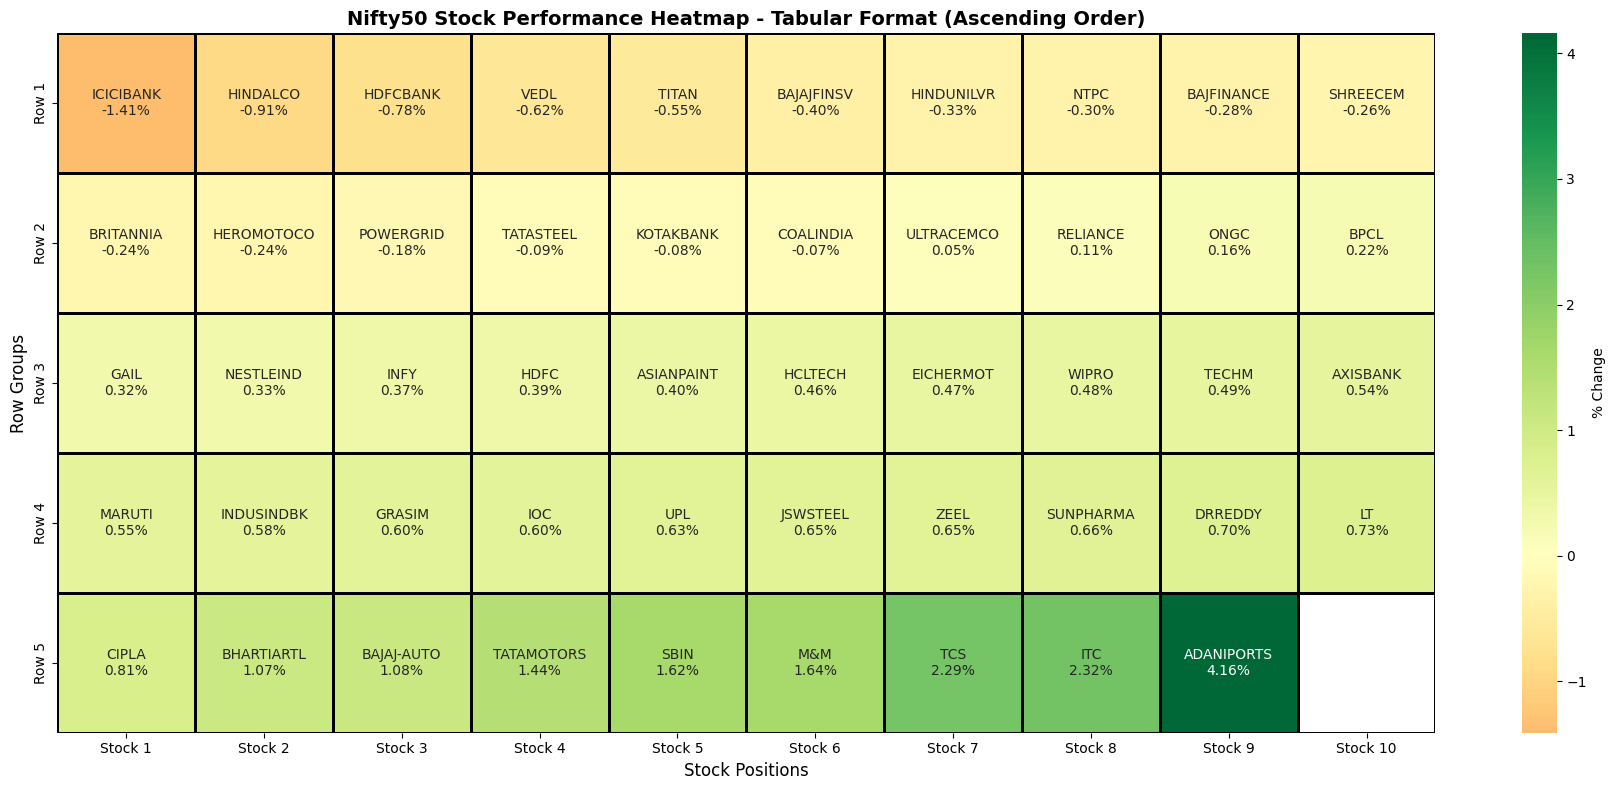

In [56]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Load the Nifty50 dataset
nifty = pd.read_excel('Nifty50.xlsx')


# Calculate percentage change from Prev Close to Close
nifty['% Change'] = ((nifty['Close'] - nifty['Prev Close']) / nifty['Prev Close'] * 100).round(2)

# Group by Symbol and calculate mean % change
stock_performance = nifty.groupby('Symbol')[['% Change', 'Close', 'Volume', '%Deliverble']].mean()

# Sort by % Change in ascending order
stock_performance_sorted = stock_performance.sort_values(by='% Change', ascending=True)

print("\n=== Stock Performance (Sorted by % Change - Ascending) ===")
print(stock_performance_sorted)

# Create tabular format with 10 stocks per row
stocks_list = stock_performance_sorted.index.tolist()
num_stocks = len(stocks_list)
stocks_per_row = 10
num_rows = (num_stocks + stocks_per_row - 1) // stocks_per_row

# Create data for heatmap - % Change values
heatmap_data = []
row_labels = []

for i in range(num_rows):
    start_idx = i * stocks_per_row
    end_idx = min(start_idx + stocks_per_row, num_stocks)
    row_stocks = stocks_list[start_idx:end_idx]
    row_values = [stock_performance_sorted.loc[stock, '% Change'] for stock in row_stocks]
    
    # Pad with NaN if row is incomplete
    while len(row_values) < stocks_per_row:
        row_values.append(np.nan)
    
    heatmap_data.append(row_values)
    row_labels.append(f"Row {i+1}")

# Create DataFrame for heatmap
heatmap_df = pd.DataFrame(heatmap_data, 
                          columns=[f"Stock {i+1}" for i in range(stocks_per_row)],
                          index=row_labels)

# Add stock symbols as values
stock_symbols_df = []
for i in range(num_rows):
    start_idx = i * stocks_per_row
    end_idx = min(start_idx + stocks_per_row, num_stocks)
    row_stocks = stocks_list[start_idx:end_idx]
    
    while len(row_stocks) < stocks_per_row:
        row_stocks.append('')
    
    stock_symbols_df.append(row_stocks)

stock_symbols_df = pd.DataFrame(stock_symbols_df,
                                columns=[f"Stock {i+1}" for i in range(stocks_per_row)],
                                index=row_labels)

# Create heatmap with % Change values
fig, ax = plt.subplots(figsize=(18, 8))

# Create annotation text combining stock symbol and % change
annot_text = []
for i in range(num_rows):
    row_text = []
    for j in range(stocks_per_row):
        if pd.notna(heatmap_df.iloc[i, j]):
            symbol = stock_symbols_df.iloc[i, j]
            value = heatmap_df.iloc[i, j]
            row_text.append(f"{symbol}\n{value:.2f}%")
        else:
            row_text.append("")
    annot_text.append(row_text)

annot_array = np.array(annot_text, dtype=object)

# Create heatmap
sns.heatmap(heatmap_df,
            annot=annot_array,
            fmt='',
            cmap='RdYlGn',
            center=0,
            cbar_kws={'label': '% Change'},
            linewidths=1,
            linecolor='black',
            ax=ax,
            vmin=stock_performance_sorted['% Change'].min(),
            vmax=stock_performance_sorted['% Change'].max())

ax.set_title('Nifty50 Stock Performance Heatmap - Tabular Format (Ascending Order)', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Row Groups', fontsize=12)
ax.set_xlabel('Stock Positions', fontsize=12)
plt.tight_layout()
plt.show()

